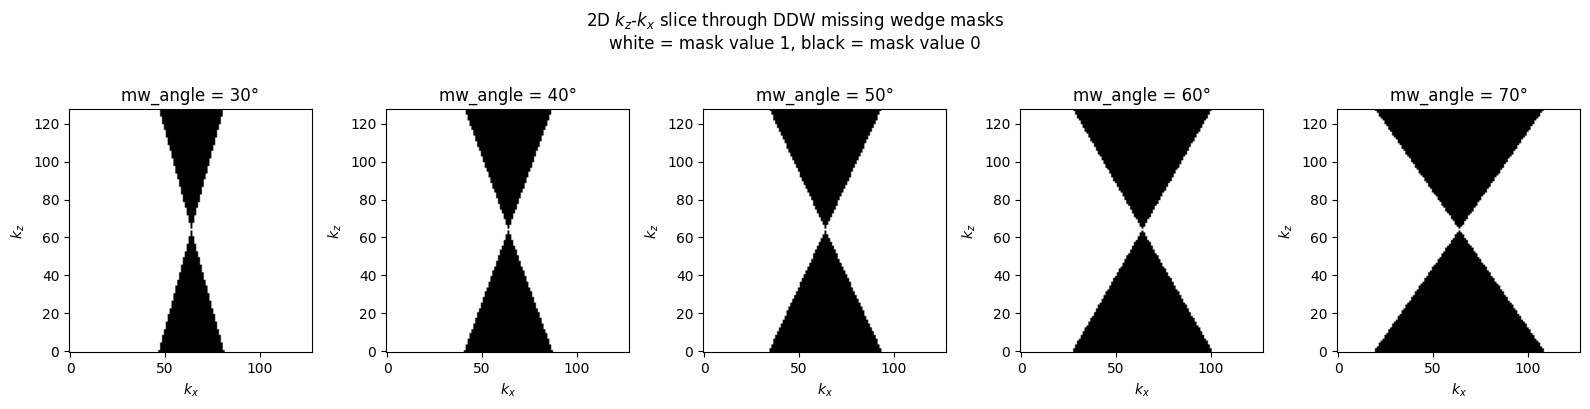

In [1]:
import torch
import matplotlib.pyplot as plt
from ddw.utils.missing_wedge import get_missing_wedge_mask

angles = [30, 40, 50, 60, 70]
grid_size = (128, 128, 128)

fig, axes = plt.subplots(1, len(angles), figsize=(16, 4))

for ax, angle in zip(axes, angles):
    mask = get_missing_wedge_mask(grid_size, mw_angle=angle)
    mid_y = mask.shape[1] // 2

    # Tensor order is [z, y, x], so this is a kz-kx slice at fixed ky.
    sl = mask[:, mid_y, :]

    ax.imshow(sl.numpy(), cmap="gray", origin="lower", vmin=0, vmax=1)
    ax.set_title(f"mw_angle = {angle}°")
    ax.set_xlabel("$k_x$")
    ax.set_ylabel("$k_z$")
    ax.axis("on")

plt.suptitle("2D $k_z$-$k_x$ slice through DDW missing wedge masks\nwhite = mask value 1, black = mask value 0")
plt.tight_layout()
plt.show()

In [2]:
fig.savefig("missing_wedge_masks_2d.png", dpi=200, bbox_inches="tight")

In [3]:
angle = 50
mask = get_missing_wedge_mask((128, 128, 128), mw_angle=angle)

fraction_ones = mask.float().mean().item()
fraction_zeros = 1 - fraction_ones

print(f"mw_angle = {angle}°")
print(f"Fraction mask == 1: {fraction_ones:.4f}")
print(f"Fraction mask == 0: {fraction_zeros:.4f}")

mw_angle = 50°
Fraction mask == 1: 0.7673
Fraction mask == 0: 0.2327


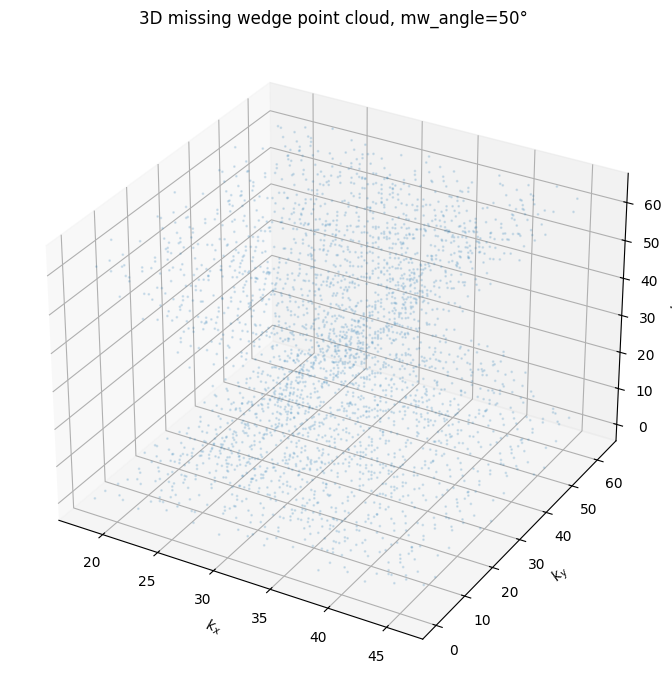

In [4]:
import torch
import matplotlib.pyplot as plt
from ddw.utils.missing_wedge import get_missing_wedge_mask

angle = 50
grid_size = (64, 64, 64)

mask = get_missing_wedge_mask(grid_size, mw_angle=angle)

# Tensor order is [z, y, x].
# We plot the zero-region as the missing wedge if mask is a keep-mask.
# If this looks inverted, switch missing = mask.
missing = 1 - mask

z, y, x = torch.where(missing > 0)

# Downsample points so plotting stays fast
step = 20
z = z[::step]
y = y[::step]
x = x[::step]

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(x.numpy(), y.numpy(), z.numpy(), s=1, alpha=0.15)

ax.set_title(f"3D missing wedge point cloud, mw_angle={angle}°")
ax.set_xlabel("$k_x$")
ax.set_ylabel("$k_y$")
ax.set_zlabel("$k_z$")

plt.tight_layout()
plt.show()

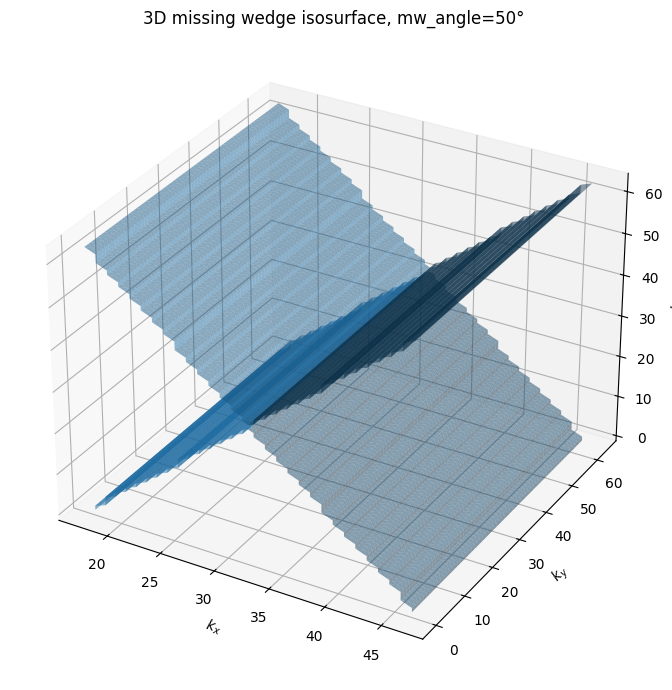

In [5]:
import torch
import matplotlib.pyplot as plt
from skimage import measure
from ddw.utils.missing_wedge import get_missing_wedge_mask

angle = 50
grid_size = (64, 64, 64)

mask = get_missing_wedge_mask(grid_size, mw_angle=angle)
missing = (1 - mask).numpy().astype(float)

verts, faces, normals, values = measure.marching_cubes(missing, level=0.5)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_trisurf(
    verts[:, 2],  # x
    verts[:, 1],  # y
    faces,
    verts[:, 0],  # z
    linewidth=0.1,
    alpha=0.5
)

ax.set_title(f"3D missing wedge isosurface, mw_angle={angle}°")
ax.set_xlabel("$k_x$")
ax.set_ylabel("$k_y$")
ax.set_zlabel("$k_z$")

plt.tight_layout()
plt.show()

In [6]:
fig.savefig("missing_wedge_masks_3d_isosurface.png", dpi=200, bbox_inches="tight")

In [7]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.device_count())

False
0


/cluster/home/fschneide/semester-project-deepdewedge/ddw-env/lib/python3.11/site-packages/torch/cuda/__init__.py:1061: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()
